# CardioRisk Prediction

## Problem Statement

CardioCare, a healthcare provider, is committed to enhancing preventative care and improving patient outcomes. With the growing prevalence of cardiovascular disease (CVD), accurate and timely risk assessment is essential. Although CardioCare might provide comprehensive medical resources, optimising doctors' valuable consultation time is crucial for efficient and effective care. At the same time, correctly identifying at-risk patients is highly important.

### Business Objective

CardioCare aims to develop a machine learning model to predict CVD risk using patient health data. This model is intended to support healthcare providers in efficiently allocating resources and optimising doctors' consultation time. By identifying patients with high risk of CVD, the model can help prioritise consultations and potentially eliminate the need for an initial consultation stage for some patients. This will allow doctors to focus their expertise on individuals requiring immediate attention.

### Assignment Tasks

You need to perform the following steps to complete this assignment:
1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis
4. Train Validation Split
5. Feature Engineering
6. Model Building
8. Prediction and Model Evaluation

**Based on this assignment, you have to answer the following questions:**

- What insights can we gain from exploring the relationships between different health metrics and the prevalence of cardiovascular disease within the patient population?

- Based on the analysis, which patient characteristics emerge as the strongest predictors of cardiovascular disease risk? Are there any surprising or unexpected findings?

- How effectively can machine learning models identify individuals at risk of developing cardiovascular disease based on their health data? How does the evaluation results vary across different models?

- How can CardioCare integrate the predictive model into their existing healthcare workflows to enhance preventative care strategies?

### Data Dictionary

The CardioRisk Prediction has 14 Columns and 70000 Rows. Following data dictionary provides the description for each column present in dataset:


<table>
  <tr>
    <th>Column Name</th>
    <th>Description</th>
  </tr>
  <tr>
    <td>Unnamed: 0</td>
    <td>Index or row number</td>
  </tr>
  <tr>
    <td>id</td>
    <td>Unique identifier for each individual in the dataset</td>
  </tr>
  <tr>
    <td>age</td>
    <td>Age of the individual, measured in days</td>
  </tr>
  <tr>
    <td>gender</td>
    <td>Gender of the individual (0: Female, 1: Male)</td>
  </tr>
  <tr>
    <td>height</td>
    <td>Height of the individual, measured in centimeters</td>
  </tr>
  <tr>
    <td>weight</td>
    <td>Weight of the individual, measured in kilograms</td>
  </tr>
  <tr>
    <td>ap_hi</td>
    <td>Systolic blood pressure reading</td>
  </tr>
  <tr>
    <td>ap_lo</td>
    <td>Diastolic blood pressure reading</td>
  </tr>
  <tr>
    <td>cholesterol</td>
    <td>Cholesterol level (0: normal, 1: above normal, 2: well above normal)</td>
  </tr>
  <tr>
    <td>gluc</td>
    <td>Glucose level (0: normal, 1: above normal, 2: well above normal)</td>
  </tr>
  <tr>
    <td>smoke</td>
    <td>Smoking status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>alco</td>
    <td>Alcohol intake status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>active</td>
    <td>Physical activity status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>cardio</td>
    <td>Presence or absence of cardiovascular disease (0: No Disease, 1: Disease)</td>
  </tr>
</table>

</body>
</html>


    
This data dictionary serves as a reference for understanding the dataset and its variables.

## **1. Data Understanding**

<font color = red>[2 marks]</font> <br>

In this stage, you have to load the dataset and check basic statistics of the data, including preview of data, dimension of data, column descriptions and data types.

In [1]:
# suggested imports; import more libraries as needed
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve, \
    confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

### **1.1 Load the dataset**

<font color = red>[2 marks]</font> <br>

In [2]:
# Load the dataset
df=pd.read_csv("health_data.csv")

#### **1.1.1** Check the first few entries

In [3]:
# Check the first few entries
df.head()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


#### **1.1.2** Remove columns which are irrelevant <font color = red>[2 marks]</font> <br>

In [4]:
# Remove irrelevant columns like unique identifiers or index
columns_to_remove=["Unnamed: 0","id"]
for col in df.columns:
  if col in columns_to_remove:
    df=df.drop(col,axis=1)
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


#### **1.1.3** Inspect the shape of the dataset

In [5]:
# Inspect the shape of the dataset
df.shape

(70000, 12)

#### **1.1.4** Inspect the different columns in the dataset

In [6]:
# Inspect the different columns in the dataset
#checking the unique values in the columns
for col in df.columns:
  if df[col].dtype=="int64":
    print(f"Unique values in column- {col} are {df[col].unique()}")

Unique values in column- gender are [1 0]
Unique values in column- cholesterol are [0 2 1]
Unique values in column- gluc are [0 1 2]
Unique values in column- smoke are [0 1]
Unique values in column- alco are [0 1]
Unique values in column- active are [1 0]
Unique values in column- cardio are [0 1]


Check the summary of the dataset

In [7]:
# Check the summary of the dataset
print("Column details:")
df.info()

Column details:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  float64
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  float64
 5   ap_lo        70000 non-null  float64
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 6.4 MB


## **2. Data Cleaning**

<font color = red>[8 marks]</font> <br>

### **2.1 Identify and handle redundant or invalid/illogical physiological values**

<font color = red>[6 marks]</font> <br>

Examine the dataset to identify any columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

- Pay attention to blood pressure values and ensure they fall within reasonable physiological limits. Very high or low values might need to be investigated or addressed. Blood pressure values less than 30 and more than 300 are rarely observed.
- Additionally, think about which unit might be more intuitive for understanding a person's age in a healthcare context.
- Similarly, reflect on the representation of height and explore whether using a different unit would align better with typical practices in healthcare and enhance the overall interpretability of the data.

#### **2.1.1** Check the statistical summary of the data <font color = red>[1 marks]</font> <br>

Examine the statistical summary to identify the columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

In [8]:
# Check the statistical summary of the data
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


#### **2.1.2** Handle rows with invalid/illogical values <font color = red>[3 marks]</font> <br>

Based on the details of data present in statistical summary, handle the columns that have invalid/illogical values or does not fall within physiological limits or have extreme values.

In [9]:
# Handle rows which have invalid or illogical values or does not fall within physiological limits (include extreme cases) for blood pressure and height etc
# Assumptions & Physiological Limits for Data Cleaning:
# 1. Blood pressure readings below 30 mmHg or above 300 mmHg are physiologically invalid / measurement errors.
# 2. Systolic blood pressure (ap_hi) must be strictly greater than diastolic blood pressure (ap_lo).
# 3. Extreme outliers in height (< 100 cm or > 250 cm) and weight (< 30 kg) are unrealistic for adult healthcare records.
df=df[
    (df['ap_hi']<=300) & (df['ap_hi']>=30) &
    (df['ap_lo']<=300) & (df['ap_lo']>=30) &
    (df['ap_hi']>df['ap_lo']) &
    (df['height']<=250) & (df['height']>=100) &
    (df['weight']>=30)
]
print(f"New row count: {df.shape[0]}")

New row count: 68646


#### **2.1.3** Modify the representation of patient age and height <font color = red>[2 marks]</font> <br>

In [10]:
# Modify the representation of patient age and height (to years and meters) for better understanding in a healthcare context
df['age']=(df['age']/365).round(2)
df['height']=(df['height']/100).round(2)
#checking the modified df
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,68646.000000,68646.000000,68646.000000,68646.000000,68646.000000,68646.000000,68646.000000,68646.000000,68646.000000,68646.000000,68646.000000,68646.000000
mean,53.328006,0.348615,1.643961,74.120224,126.676441,81.303397,0.364726,0.225782,0.087944,0.053346,0.803368,0.494741
std,6.761693,0.476535,0.079835,14.306733,16.695541,9.466443,0.678927,0.571644,0.283215,0.224724,0.397455,0.499976
min,29.580000,0.000000,1.000000,30.000000,60.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.380000,0.000000,1.590000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,53.980000,0.000000,1.650000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,58.420000,1.000000,1.700000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,64.970000,1.000000,2.500000,200.000000,240.000000,182.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,68646.000000,68646.000000,68646.000000,68646.000000,68646.000000,68646.000000,68646.000000,68646.000000,68646.000000,68646.000000,68646.000000,68646.000000
mean,53.328006,0.348615,1.643961,74.120224,126.676441,81.303397,0.364726,0.225782,0.087944,0.053346,0.803368,0.494741
std,6.761693,0.476535,0.079835,14.306733,16.695541,9.466443,0.678927,0.571644,0.283215,0.224724,0.397455,0.499976
min,29.580000,0.000000,1.000000,30.000000,60.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.380000,0.000000,1.590000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,53.980000,0.000000,1.650000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,58.420000,1.000000,1.700000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,64.970000,1.000000,2.500000,200.000000,240.000000,182.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


### **2.2 Fix DataTypes**

<font color = red>[2 marks]</font> <br>

#### **2.2.1** Review and fix the data types of all columns <font color = red>[2 marks]</font> <br>

Ensuring the columns accurately reflect the nature of the data

In [12]:
# Fix DataTypes of the categorical columns with incorrect DataTypes
categorical_columns=["gender","cholesterol","gluc","smoke","alco","active"]
for col in categorical_columns:
  df[col]=df[col].astype("category")

In [13]:
# Check the final data types post conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68646 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   age          68646 non-null  float64 
 1   gender       68646 non-null  category
 2   height       68646 non-null  float64 
 3   weight       68646 non-null  float64 
 4   ap_hi        68646 non-null  float64 
 5   ap_lo        68646 non-null  float64 
 6   cholesterol  68646 non-null  category
 7   gluc         68646 non-null  category
 8   smoke        68646 non-null  category
 9   alco         68646 non-null  category
 10  active       68646 non-null  category
 11  cardio       68646 non-null  int64   
dtypes: category(6), float64(5), int64(1)
memory usage: 4.1 MB


## **3. Exploratory Data Analysis**

<font color = red>[27 marks]</font>

### **3.1 Perform univariate analysis**

<font color = red>[12 marks]</font>

#### **3.1.1** Visualise the numerical features <font color = red>[5 marks]</font>

Visualise the distribution of numerical features using appropriate plots to understand their characteristics.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68646 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   age          68646 non-null  float64 
 1   gender       68646 non-null  category
 2   height       68646 non-null  float64 
 3   weight       68646 non-null  float64 
 4   ap_hi        68646 non-null  float64 
 5   ap_lo        68646 non-null  float64 
 6   cholesterol  68646 non-null  category
 7   gluc         68646 non-null  category
 8   smoke        68646 non-null  category
 9   alco         68646 non-null  category
 10  active       68646 non-null  category
 11  cardio       68646 non-null  int64   
dtypes: category(6), float64(5), int64(1)
memory usage: 4.1 MB


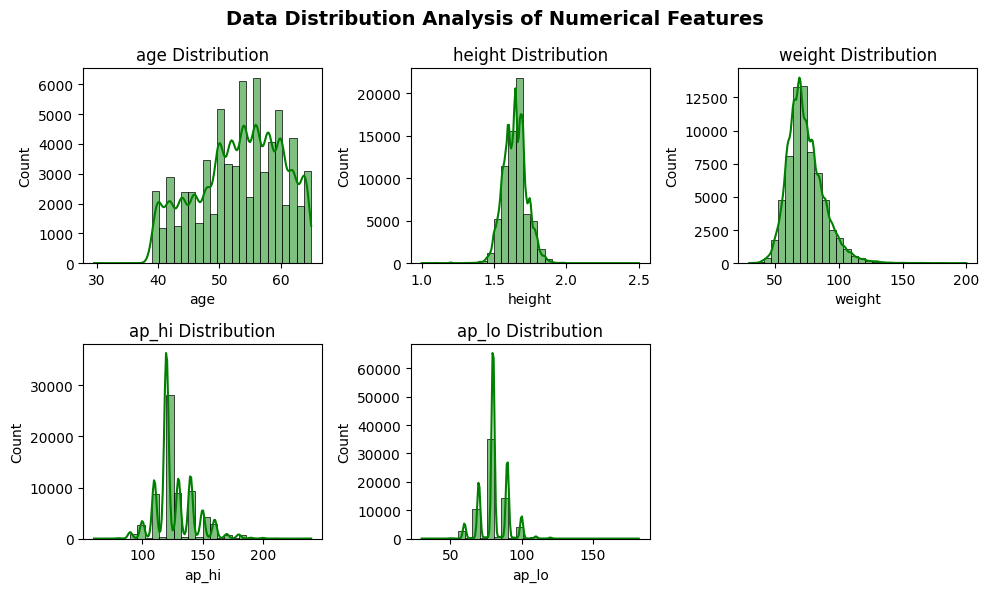

In [15]:
# Plot all the numerical columns to understand their distribution
#creating a subplot grid
fig,axs=plt.subplots(2,3,figsize=(10,6))
fig.suptitle("Data Distribution Analysis of Numerical Features", fontsize=14, fontweight='bold')
#flattening the axes for smooth handling and placcing the plots
axes_flat=axs.flatten()
#tracking the plotting index
plotting_index=0

for col in df.columns:
  if df[col].dtype=="float64":
    if plotting_index<len(axes_flat):
      #current plotting index
      current_ax=axes_flat[plotting_index]
      #plotting and decorating the plots
      sns.histplot(data=df,x=col,bins=30,ax=current_ax,kde=True,color="green")
      current_ax.set_title(f"{col} Distribution")
      current_ax.set_xlabel(f"{col}")
      #increasing hte tracking index by 1
      plotting_index+=1
#delecting extra spaces
for i in range(plotting_index,len(axes_flat)):
  fig.delaxes(axes_flat[i])
plt.tight_layout()
plt.show()



#### **3.1.2** Visualise the categorical features <font color = red>[5 marks]</font>

Visualise the distribution of categorical features to get a clear view of the data distribution across various categories. This will help in identifying potential imbalances or dominant categories.

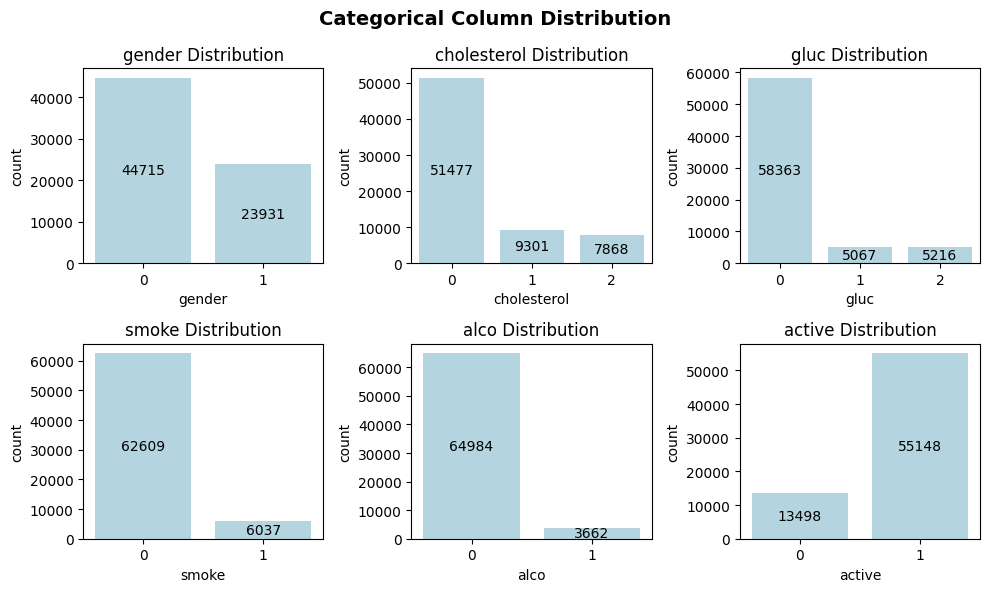

In [16]:
# Select and plot categorical columns
#creating a subplot grid
fig,axs=plt.subplots(2,3,figsize=(10,6))
#creating a super title for the figure
fig.suptitle("Categorical Column Distribution",fontsize=14,fontweight="bold")
#flattening the axes
flat_axes=axs.flatten()
#plotting index tracker
plotting_index=0

#plotting the chart
for col in df.columns:
  if df[col].dtypes=="category":
    if plotting_index<len(flat_axes):
      current_axes=flat_axes[plotting_index]
      sns.countplot(data=df,x=col,ax=current_axes,color="lightblue")
      current_axes.set_title(f"{col} Distribution")
      current_axes.set_xlabel(f"{col}")
      current_axes.bar_label(current_axes.containers[0],label_type='center')
      plotting_index+=1

#removing extra space
for i in range(plotting_index,len(flat_axes)):
  fig.plt.delaxes(flat_axes[i])

plt.tight_layout()
plt.show()


#### **3.1.3** Check class distribution of the target feature <font color = red>[2 marks]</font>

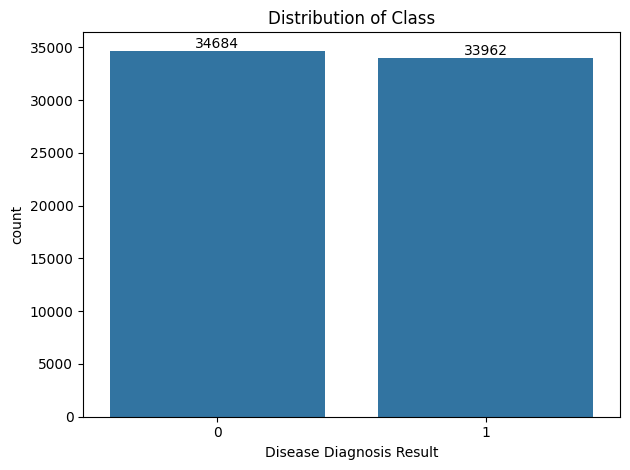

In [17]:
# Class distribution of positive and negative classes
ax=sns.countplot(data=df,x="cardio")
plt.xlabel("Disease Diagnosis Result")
plt.title("Distribution of Class")
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

### **3.2 Perform correlation analysis**

<font color = red>[5 marks]</font>

Investigate the relationships between numerical features to identify potential multicollinearity or dependencies. Visualise the correlation structure using an appropriate method to gain insights into feature relationships

#### **3.2.1** Visualise the correlation among numerical features <font color="red">[5 Marks]</font>


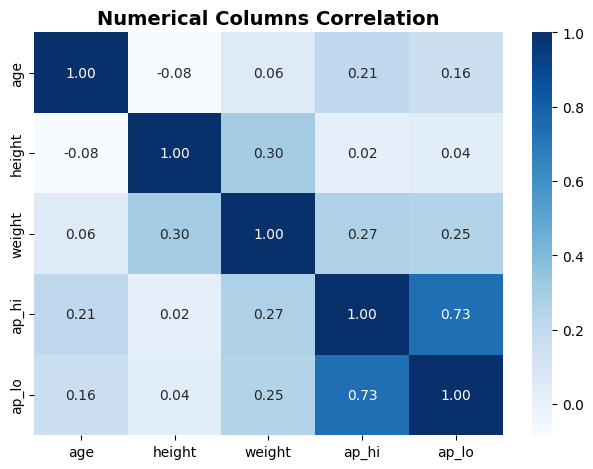

In [18]:
# Plot Heatmap of the correlation matrix
#numerical columns
numerical_columns=df.select_dtypes(include=["float64"]).columns
#correlation between the df columns
c=df[numerical_columns].corr()
#plotting in heatmap
sns.heatmap(data=c,annot=True,fmt=".2f", cmap="Blues")
plt.title("Numerical Columns Correlation",fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

### **3.3 Perform bivariate analysis**

<font color = red>[10 marks]</font>

#### **3.3.1** Analyse categorical features <font color="red">[5 Marks]</font>

For each categorical feature (excluding the target), calculate the proportion of `cardio = 1` in each category of the feature. Use this to identify which categorical features show clear differences in heart disease likelihood and which are less informative.

In [19]:
# Write a function to analyse the target variable likelihood for categorical features
def categorical_feature_analyser(df: pd.DataFrame,cat_cols: list ) -> None:
  target_col=df.columns[-1]
  for col in cat_cols:
    print(f"\n{col} proportion to 'cardio=1'")
    result=df.groupby([col])[target_col].mean().reset_index()
    print(f"{result}")
categorical_feature_analyser(df,categorical_columns)


gender proportion to 'cardio=1'
  gender    cardio
0      0  0.492117
1      1  0.499645

cholesterol proportion to 'cardio=1'
  cholesterol    cardio
0           0  0.435457
1           1  0.596280
2           2  0.762583

gluc proportion to 'cardio=1'
  gluc    cardio
0    0  0.475610
1    1  0.588711
2    2  0.617523

smoke proportion to 'cardio=1'
  smoke    cardio
0     0  0.497277
1     1  0.468445

alco proportion to 'cardio=1'
  alco    cardio
0    0  0.495768
1    1  0.476516

active proportion to 'cardio=1'
  active    cardio
0      0  0.532746
1      1  0.485439


#### **3.3.2** Explore the relationships between numerical features and the target variable <font color = red>[5 marks]</font>

Understand the impact of numeric features on the target outcome using appropriate visualisation techniques to identify trends and potential interactions

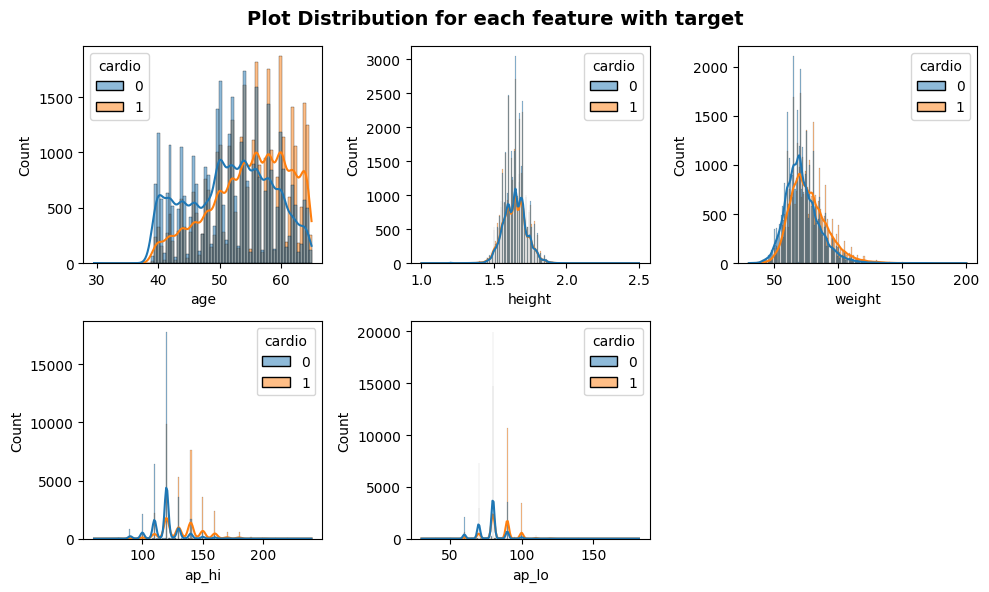

In [20]:
# Plot distribution for each numerical column with target variable
fig,axs=plt.subplots(2,3,figsize=(10,6))
fig.suptitle("Plot Distribution for each feature with target",fontsize=14,fontweight='bold')
flatten_axs=axs.flatten()
plotting_indx=0
#plotting
for col in numerical_columns:
  current_axs=flatten_axs[plotting_indx]
  sns.histplot(data=df,x=col,ax=current_axs,hue="cardio",kde=True)
  plotting_indx+=1
#removing extra space
for i in range(plotting_indx,len(flatten_axs)):
  fig.delaxes(flatten_axs[i])

plt.tight_layout()
plt.show()

## **4. Train-Test Split**

<font color = red>[5 marks]</font>

### **4.1 Data Splitting**

<font color = red>[5 Marks]</font>

#### **4.1.1** Define feature and target variables <font color = red>[2 Marks]</font>

In [21]:
# Put all the feature variables in X and target in y
X=df.drop("cardio",axis=1)
y=df["cardio"]
print(X.shape)
print(y.shape)

(68646, 11)
(68646,)


#### **4.1.2** Split the data into train and test sets <font color="red">[3 Marks]</font>

Split the data in 0.7:0.3 sets. and reset the index for the sets. Check the shape of the test and test sets.


In [22]:
#  Split the data into 70% train data and 30% test data
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.3,stratify=y,random_state=42)

In [23]:
# Reset index for all train and test sets
X_train=X_train.reset_index(drop=True)
X_test=X_test.reset_index(drop=True)
y_train=y_train.reset_index(drop=True)
y_test=y_test.reset_index(drop=True)
print(f"X_train shape: \n{X_train.shape},\nX_test shape: \n{X_test.shape},\ny_train shape: \n{y_train.shape},\ny_test shape: \n{y_test.shape}")

X_train shape: 
(48052, 11),
X_test shape: 
(20594, 11),
y_train shape: 
(48052,),
y_test shape: 
(20594,)


## **5. Feature Engineering**

<font color = red>[18 marks]</font>

### **5.1 Create a new feature**

<font color = red>[6 marks]</font>

#### **5.1.1** Create a new feature `BMI` (Body Mass Index) <font color="red">[3 Marks]</font>

BMI is a standard health metric calculated using a person's height and weight. BMI is known to be a useful predictor for cardiovascular risk.

In [24]:
# Create a new feature 'BMI'
X_train["BMI"]=X_train['weight']/X_train['height']**2
X_test["BMI"]=X_test['weight']/X_test['height']**2

**Note:** Feel free to engineer more features if you wish to.

#### **5.1.2** Perform correlation analysis  <font color="red">[3 Marks]</font>

After creating the new feature `BMI`, perform correlation analysis to check if it's correlated with any existing features. Perform suitable processing steps if high correlation is found.

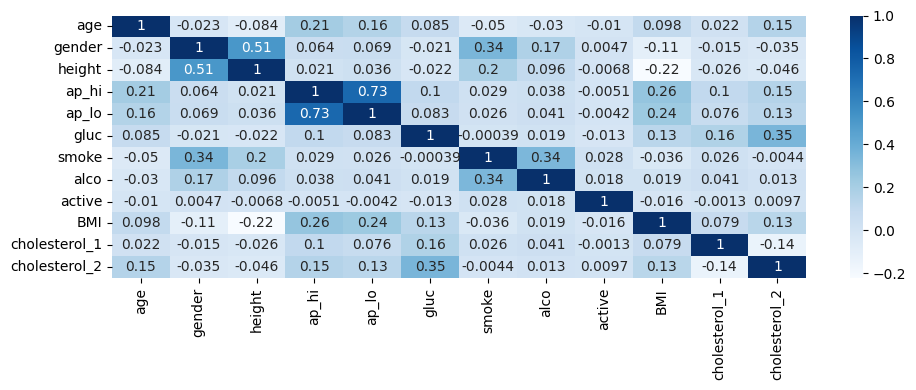

In [69]:
# Plot check correlation
cr=X_train.corr()
plt.figure(figsize=(10,4))
sns.heatmap(data=cr,cmap="Blues",annot=True)
plt.tight_layout()

In [26]:
# Did you find any highly correlated features? What steps should you take
'''Primary Correlation: A strong positive correlation exists between BMI and weight (r = 0.85) because BMI is directly calculated using weight. As a
reason dropping this feature for multicollinearity.
Secondary Correlation: A strong correlation between ap_hi and ap_lo (r = 0.73). However, retaining them as they represent distinct
indicators(systolic and diastolic pressure).'''
X_train=X_train.drop("weight",axis=1)
X_test=X_test.drop("weight",axis=1)

### **5.2 Combine Values in Categorical Columns**

<font color="red">[4 Marks]</font>

#### **5.2.1** Combine Low-Frequency Categories <font color="red">[4 Marks]</font>

During the EDA process, categorical columns with multiple unique levels may be identified. To enhance model performance, it is recommended to refine these categorical features by grouping values that have low frequency or provide limited predictive information.

Combine categories that occur infrequently or exhibit similar behavior to reduce sparsity and improve model generalisation.

In [27]:
#current categories frequency for X_train
print("Category-wise frequency displayed(X_train):")
for col in categorical_columns:
  print(f"\n{X_train[col].value_counts(normalize=True)}")

Category-wise frequency displayed(X_train):

gender
0    0.650941
1    0.349059
Name: proportion, dtype: float64

cholesterol
0    0.748148
1    0.135437
2    0.116416
Name: proportion, dtype: float64

gluc
0    0.849330
2    0.076209
1    0.074461
Name: proportion, dtype: float64

smoke
0    0.911617
1    0.088383
Name: proportion, dtype: float64

alco
0    0.945913
1    0.054087
Name: proportion, dtype: float64

active
1    0.803505
0    0.196495
Name: proportion, dtype: float64


In [28]:
# Combine categories that have low frequency or provide limited predictive information such as gluc and cholesterol
'''Considering the proportion combining categories only for 'gluc' feature, as 'cholesterol' have significant contribution for both
level 1 and level 2(13.54%, and 11.64%).'''
#Comnine category dictionary
combine_cat={
    0:0,
    1:1,
    2:1
}
#Combining low-frequency categories to 'normal' and 'above-normal'
X_train["gluc"]=X_train["gluc"].replace(combine_cat)
X_test["gluc"]=X_test["gluc"].map(lambda x: combine_cat[x])
print("Changed X_train gluc proportion:\n", X_train['gluc'].value_counts(normalize=True))
print("\n Changed X_test gluc proportion:\n", X_test['gluc'].value_counts(normalize=True))

Changed X_train gluc proportion:
 gluc
0    0.84933
1    0.15067
Name: proportion, dtype: float64

 Changed X_test gluc proportion:
 gluc
0    0.852239
1    0.147761
Name: proportion, dtype: float64


### **5.3 Dummy variable creation**

<font color = red>[5 marks]</font>

#### **5.3.1** Create dummy variables for categorical columns <font color="red">[5 Mark]</font>

In [29]:
# Identify the columns for creating dummy variables
"""There is a single feature remaining that need to be created dummy variable. And it is 'cholesterol' column, that need the transformation"""

"There is a single feature remaining that need to be created dummy variable. And it is 'cholesterol' column, that need the transformation"

In [30]:
# Create dummy variables for independent columns on training data
X_train=pd.get_dummies(X_train,columns=['cholesterol'],drop_first=True,dtype='int')

In [31]:
# Create dummy variables for independent columns on test data
X_test=pd.get_dummies(X_test,columns=['cholesterol'],drop_first=True,dtype='int')

### **5.4 Feature scaling**

<font color = red>[3 marks]</font>

#### **5.4.1** Scale numerical features <font color = red>[3 marks]</font>

Choose a scaling method appropriate for the data and the chosen model. Apply the same scaling to both training and test data.

In [32]:
# Scale the numeric features present in the training data
scale=MinMaxScaler()
X_train_scaled=pd.DataFrame(scale.fit_transform(X_train),columns=X_train.columns,index=X_train.index)
# Scale the numerical features present in the test data
X_test_scaled=pd.DataFrame(scale.transform(X_test),columns=X_test.columns,index=X_test.index)

In [33]:
#checking the shape and columns for scaled datasets
print("Train shape:",X_train_scaled.shape,"| Test shape:",X_test.shape)
print("Same Columns:",list(X_train_scaled.columns)==list(X_test_scaled.columns))

Train shape: (48052, 12) | Test shape: (20594, 12)
Same Columns: True


## **6. Model Building**

<font color = red>[38 marks]</font>

In this task, you will build the two machine learning models: Support Vector Classifier (SVC) and a Decision Tree classifier. We will follow the same structured workflow for the models:

* *Model Building and Initial Evaluation*: <br> Fit the model and evaluate its performance on the training data using the default cutoff
* *Find the Optimal Cutoff*: <br> Determine the best probability threshold using sensitivity-specificity and precision–recall trade-offs
* *Model Prediction & Evaluation using chosen cutoff*: <br> Generate predictions using the chosen cutoff and evaluate performance on the training data
* *Hyperparameter Tuning (Grid Search)*: <br> Optimise performance using grid search for hyperparameter tuning
* *Final Model Training & Evaluation using chosen cutoff*: <br> Train the final model using the best hyperparameters and evaluate performance on the training data

### **6.1 SVM Classifier**

<font color = red>[18 marks]</font>

#### **6.1.1** Define a Linear SVM classifier and fit it on the train set <font color = red>[2 mark]</font>

Go through the [SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) and define a model with linear kernel that will also return the probabilities estimates of the predictions.

In [34]:
# Define and fit linear SVM
svm=SVC(kernel='linear',probability=True)
svm.fit(X_train_scaled,y_train)

SVC(kernel='linear', probability=True)

#### **6.1.2** Get the probability estimates on test set and predict class using a threshold <font color = red>[3 mark]</font>

We defined the model to also return the probabilities after training. Use the `SVC.predict_proba()`[(documentation)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC.predict_proba) function to fetch the probabilities on test set. For each sample, it returns the probabilities of each class in a sorted order (according to `SVC.classes_`)

After getting the probability values, assign class labels using the default threshold of 0.5 and check the distribution of assigned labels.

In [35]:
# Use predict_proba() to get the probability of positive class for all data points
pred_prob=svm.predict_proba(X_test_scaled)
pred_prob

array([[0.31298494, 0.68701506],
       [0.28446404, 0.71553596],
       [0.55158312, 0.44841688],
       ...,
       [0.67777268, 0.32222732],
       [0.5094636 , 0.4905364 ],
       [0.18667853, 0.81332147]])

In [36]:
# Make class predictions based on default cutoff value of 0.5 on testing data
class_pred_proba=(pred_prob[:,1]>=0.5).astype('int')
class_pred_proba

array([1, 1, 0, ..., 0, 0, 1])

In [37]:
# check the counts of assigned labels
pd.Series(class_pred_proba).value_counts()

,count
0,11889
1,8705


#### **6.1.3** Predict the class labels using the `predict()` function <font color = red>[2 mark]</font>

Now, directly use the `predict()` function to predict the class labels and check the distribution of assigned labels using this method.

In [38]:
# Make class predictions using predict()
class_pred=svm.predict(X_test_scaled)

In [39]:
# check the counts of assigned labels
pd.Series(class_pred).value_counts()

,count
0,12434
1,8160


Did you find any difference in the distribution of classes in the predictions using these two methods? Why do you think that is?

Try going through the documentation of `predict_proba()` linked above.

#### **6.1.4** Calculate performance metrics for both the above methods <font color = red>[3 mark]</font>

Calculate the performance metrics for both `predict_proba()` and `predict()` estimates. Compare the results and choose one to continue ahead.

In [40]:
# check the performance for above two methods
proba_perf=classification_report(y_test,class_pred_proba)
pred_perf=classification_report(y_test,class_pred)
print(f"Predict_Proba_Method(Threshold=0.5): \n{proba_perf}\n\nPredict_Method(Hyperplane): \n{pred_perf}")

Predict_Proba_Method(Threshold=0.5): 
              precision    recall  f1-score   support

           0       0.70      0.79      0.74     10405
           1       0.75      0.64      0.70     10189

    accuracy                           0.72     20594
   macro avg       0.73      0.72      0.72     20594
weighted avg       0.72      0.72      0.72     20594


Predict_Method(Hyperplane): 
              precision    recall  f1-score   support

           0       0.69      0.82      0.75     10405
           1       0.77      0.62      0.69     10189

    accuracy                           0.72     20594
   macro avg       0.73      0.72      0.72     20594
weighted avg       0.73      0.72      0.72     20594



Comparison and Decision:

Although both methods give the same overall accuracy (72%), predict_proba() is better for our problem because it gets a higher recall for CVD patients (0.65 vs 0.62) and a slightly better F1-score (0.70 vs 0.69).

**Since this is a medical dataset, catching as many actual CVD cases as possible (higher recall) is more important than slightly higher precision.

So, I am choosing predict_proba() to continue with the next steps.

#### **6.1.5** Plot the ROC curve <font color="red">[2 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

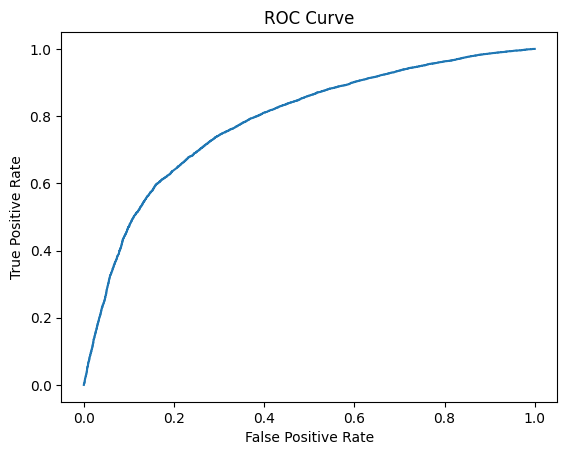

In [41]:
# Plot the ROC curve
fpr,tpr,threshhold=roc_curve(y_test,pred_prob[:,1])
plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

#### **6.1.6** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[3 Marks]</font>

In [42]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs
probability_cut_offs=[i/100 for i in range(101)]
metrics=[]
for cut_off in probability_cut_offs:
  y_pred=(pred_prob[:,1]>cut_off).astype('int')
  acc_sc=accuracy_score(y_test,y_pred)
  sensitivity=recall_score(y_test,y_pred)
  specificity=recall_score(y_test,y_pred,pos_label=0)
  metrics.append({
      "cutoff": cut_off,
      "accuracy":acc_sc,
      "sensitivity":sensitivity,
      "specificity":specificity
  })

metrics_in_different_cutoff=pd.DataFrame(metrics)
metrics_in_different_cutoff.head()

,cutoff,accuracy,sensitivity,specificity
0,0.00,0.494756,1.000000,0.000000
1,0.01,0.494756,1.000000,0.000000
2,0.02,0.494804,1.000000,0.000096
3,0.03,0.495047,1.000000,0.000577
4,0.04,0.495727,0.999902,0.002018


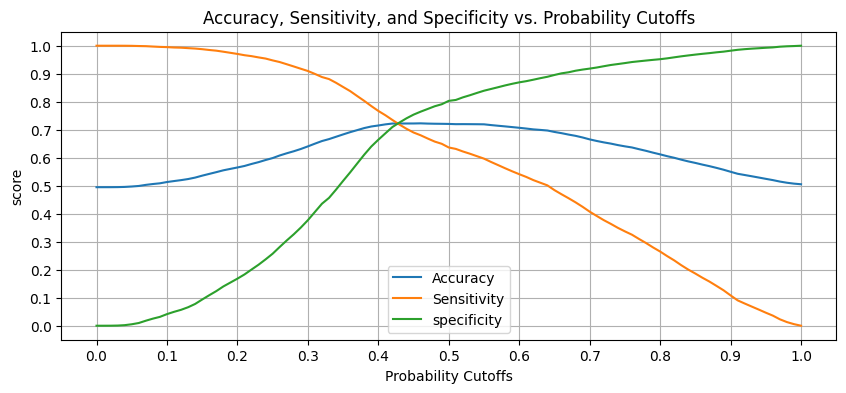

In [43]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs stored in DF
plt.figure(figsize=(10,4))
plt.plot(metrics_in_different_cutoff['cutoff'],metrics_in_different_cutoff['accuracy'],label="Accuracy")
plt.plot(metrics_in_different_cutoff['cutoff'],metrics_in_different_cutoff['sensitivity'],label="Sensitivity")
plt.plot(metrics_in_different_cutoff['cutoff'],metrics_in_different_cutoff['specificity'],label="specificity")
plt.title('Accuracy, Sensitivity, and Specificity vs. Probability Cutoffs')
plt.xlabel("Probability Cutoffs")
plt.ylabel("score")
plt.xticks(np.arange(0,1.1,.1))
plt.yticks(np.arange(0,1.1,.1),)
plt.legend()
plt.grid(True)
plt.show()

**The sensitivity and specificity lines cross each other around 0.42 to 0.43, where both reach a score of about 0.72 and accuracy is at its highest.**

**Because of this, a cutoff around 0.42 works as the best decision threshold to balance catching true positive cases while keeping false negatives low for cardiovascular disease prediction.**

To minimise the risk of missing high cardiovascular risk individuals, we should prioritise our model's ability to correctly identify those with cardiovascular disease.

#### **6.1.7** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [44]:
# Make final prediction based on the optimal cutoff
optimal_cutoff=0.42
optimal_y_pred_class=(pred_prob[:,1]>=0.42).astype('int')

In [45]:
# Evaluate the model performance
optimal_model_perf=classification_report(y_test,optimal_y_pred_class)
print(optimal_model_perf)

              precision    recall  f1-score   support

           0       0.73      0.71      0.72     10405
           1       0.71      0.73      0.72     10189

    accuracy                           0.72     20594
   macro avg       0.72      0.72      0.72     20594
weighted avg       0.72      0.72      0.72     20594



In [46]:
# Check performance on training data
y_train_pred_prob=svm.predict_proba(X_train_scaled)
y_train_pred_prob_class=(y_train_pred_prob[:,1]>0.42).astype('int')
training_perf=classification_report(y_train,y_train_pred_prob_class)
print(training_perf)

              precision    recall  f1-score   support

           0       0.74      0.71      0.73     24279
           1       0.72      0.75      0.73     23773

    accuracy                           0.73     48052
   macro avg       0.73      0.73      0.73     48052
weighted avg       0.73      0.73      0.73     48052



#### **6.1.8** Plot precision-recall curve <font color="red">[1 Mark]</font>

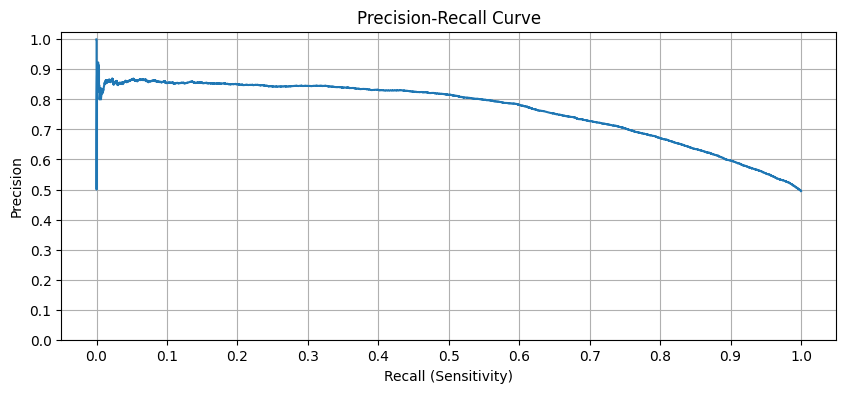

In [47]:
# Compute precision–recall values and plot for various thresholds
precision,recall,threshhold=precision_recall_curve(y_test,pred_prob[:,1])
plt.figure(figsize=(10,4))
plt.plot(recall, precision)
plt.xticks(np.arange(0,1.1,.1))
plt.yticks(np.arange(0,1.1,.1))
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

Since we want to prioritise recall/sensitivity over precision to minimise the risk of missing high-risk individuals, we can choose an agreeable cutoff value.

### **6.2 Decision Tree Classifier**

<font color = red>[12 marks]</font>

#### **6.2.1** Define a Decision Tree classifier and fit it on the train set <font color = red>[1 mark]</font>

In [48]:
# Define and fit
dtc=DecisionTreeClassifier(criterion='gini',random_state=42)
dtc.fit(X_train_scaled,y_train)

DecisionTreeClassifier(random_state=42)

#### **6.2.2** Get feature importance scores <font color = red>[2 Marks]</font>

In [49]:
# Get feature importance scores from the trained model

feature_importance=dtc.feature_importances_
features=X_train_scaled.columns
zipped=zip(features,feature_importance)
print(pd.DataFrame(zipped,columns=["Features","Importance"]))

         Features  Importance
0             age    0.282346
1          gender    0.020747
2          height    0.129010
3           ap_hi    0.230998
4           ap_lo    0.038510
5            gluc    0.014846
6           smoke    0.009743
7            alco    0.006486
8          active    0.015534
9             BMI    0.215701
10  cholesterol_1    0.013087
11  cholesterol_2    0.022992


#### **6.2.3** Predict the class probabilities on the test set <font color="red">[1 Mark]</font>

Use `predict_proba()` to get the probability estimates

In [50]:
# Predict the class probabilities
y_pred_prob_dt=dtc.predict_proba(X_test_scaled)
y_pred_prob_dt

array([[1., 0.],
       [0., 1.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

####  **6.2.4** Make prediction based on default cutoff value of 0.5 on testing data <font color = "red">[1 Mark]</font>

In [51]:
# Make prediction based on default cutoff value of 0.5
y_pred_prob_dt_default_cutoff=(y_pred_prob_dt[:,1]>=0.5).astype('int')


####  **6.2.5** Evaluate the performance of the model <font color = "red">[1 Mark]</font>

In [52]:
# Evaluate the performance of the model on training data
y_train_pred_prob_dt=(dtc.predict_proba(X_train_scaled)[:,1]>=0.5).astype('int')
dt_training_perf=classification_report(y_train,y_train_pred_prob_dt)
print(dt_training_perf)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24279
           1       1.00      1.00      1.00     23773

    accuracy                           1.00     48052
   macro avg       1.00      1.00      1.00     48052
weighted avg       1.00      1.00      1.00     48052



#### **6.2.6** Plot the ROC curve <font color="red">[1 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

In [53]:
dtc.predict_proba(X_test_scaled)

array([[1., 0.],
       [0., 1.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

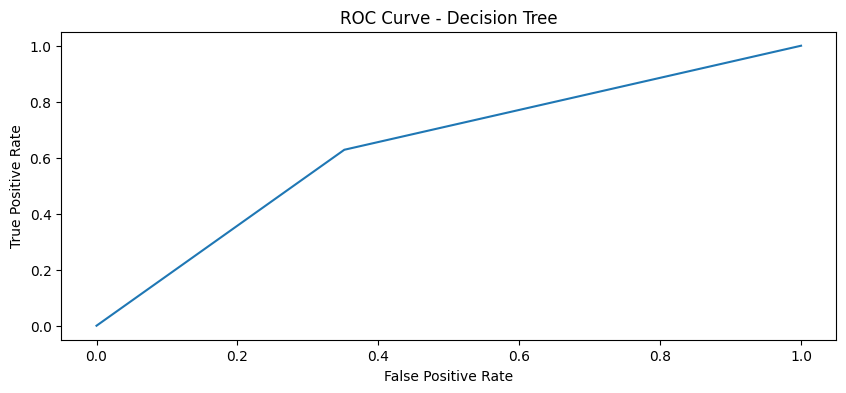

In [54]:
# Plot the ROC curve
fpr,tpr,thrershold=roc_curve(y_test,dtc.predict_proba(X_test_scaled)[:,1])
plt.figure(figsize=(10,4))
plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.show()


**Sensitivity and Specificity tradeoff**

Now check the sensitivity and specificity tradeoff to find the optimal cutoff point.

#### **6.2.7** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[2 Marks]</font>

In [55]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs
dt_metrics=[]
for cut_off in probability_cut_offs:
  y_pred_cutoff=(y_pred_prob_dt[:, 1] >= cut_off).astype('int')
  accuracy=accuracy_score(y_test,y_pred_cutoff)
  sensitivity=recall_score(y_test,y_pred_cutoff)
  specificity=recall_score(y_test,y_pred_cutoff,pos_label=0)
  dt_metrics.append({
      "cutoff":cut_off,
      "accuracy":accuracy,
      "sensitivity":sensitivity,
      "specificity":specificity
  })
metrics_in_different_cutoff_dt=pd.DataFrame(dt_metrics)
metrics_in_different_cutoff_dt.head()


,cutoff,accuracy,sensitivity,specificity
0,0.00,0.494756,1.000000,0.000000
1,0.01,0.638244,0.628914,0.647381
2,0.02,0.638244,0.628914,0.647381
3,0.03,0.638244,0.628914,0.647381
4,0.04,0.638244,0.628914,0.647381


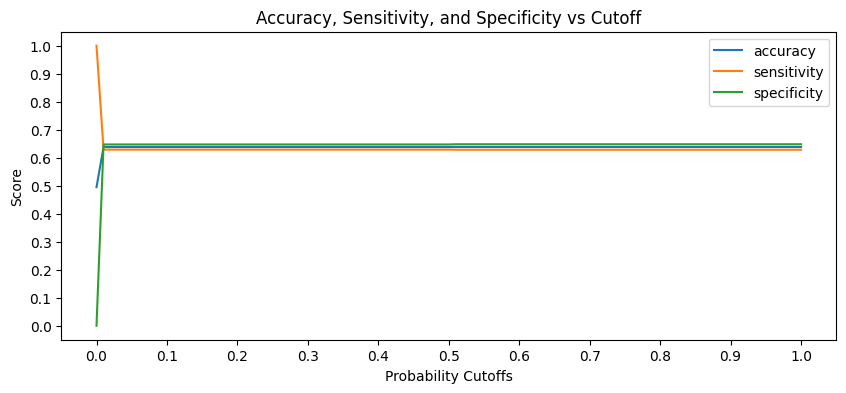

In [56]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs
plt.figure(figsize=(10,4))
plt.plot(metrics_in_different_cutoff_dt['cutoff'],metrics_in_different_cutoff_dt['accuracy'],label="accuracy")
plt.plot(metrics_in_different_cutoff_dt['cutoff'],metrics_in_different_cutoff_dt['sensitivity'],label="sensitivity")
plt.plot(metrics_in_different_cutoff_dt['cutoff'],metrics_in_different_cutoff_dt['specificity'],label="specificity")
plt.xticks(np.arange(0,1.1,.1))
plt.yticks(np.arange(0,1.1,.1))
plt.xlabel("Probability Cutoffs")
plt.ylabel("Score")
plt.title("Accuracy, Sensitivity, and Specificity vs Cutoff")
plt.legend()
plt.show()



#### **6.2.8** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [57]:
# Make final prediction based on the optimal cutoff
'''As the plot is constant throughout, taking the default 0.5 as cutoff'''
y_pred_prob_dt_final=y_pred_prob_dt_default_cutoff

In [58]:
# Evaluate the model performance for test and train
dt_model_perf_on_test_data=classification_report(y_test,y_pred_prob_dt_final)
dt_model_perf_on_training_data=dt_training_perf
print(f"Model Performance for Test Data:\n{dt_model_perf_on_test_data}\n\nModel Performance for Training Data:\n{dt_model_perf_on_training_data}")


Model Performance for Test Data:
              precision    recall  f1-score   support

           0       0.64      0.65      0.64     10405
           1       0.64      0.63      0.63     10189

    accuracy                           0.64     20594
   macro avg       0.64      0.64      0.64     20594
weighted avg       0.64      0.64      0.64     20594


Model Performance for Training Data:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24279
           1       1.00      1.00      1.00     23773

    accuracy                           1.00     48052
   macro avg       1.00      1.00      1.00     48052
weighted avg       1.00      1.00      1.00     48052



**Precision and Recall tradeoff**

Check optimal cutoff value by plotting precision-recall curve, and adjust the cutoff based on precision and recall tradeoff if required.

#### **6.2.9** Plot precision-recall curve <font color="red">[1 Mark]</font>

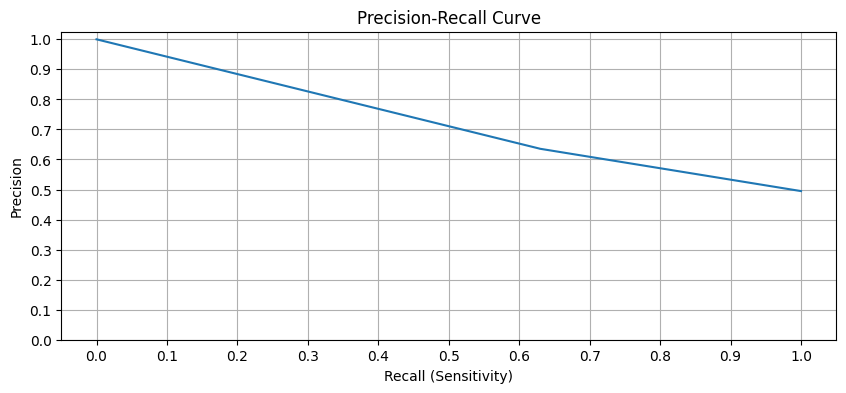

In [59]:
# Compute and plot precision–recall values
precision,recall,threshhold=precision_recall_curve(y_test,y_pred_prob_dt[:, 1])
plt.figure(figsize=(10,4))
plt.plot(recall,precision)
plt.xticks(np.arange(0,1.1,.1))
plt.yticks(np.arange(0,1.1,.1))
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

#### **6.2.10** Build another model of your choice.

Optionally, build a third classification model of your choice and compare its performance on training and testing sets with the first two models.

In [70]:
# Third model of your choice
#Working on Logistic Regression
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression(random_state=42)
LR.fit(X_train_scaled,y_train)
y_pred_prob_LR=LR.predict_proba(X_test_scaled)

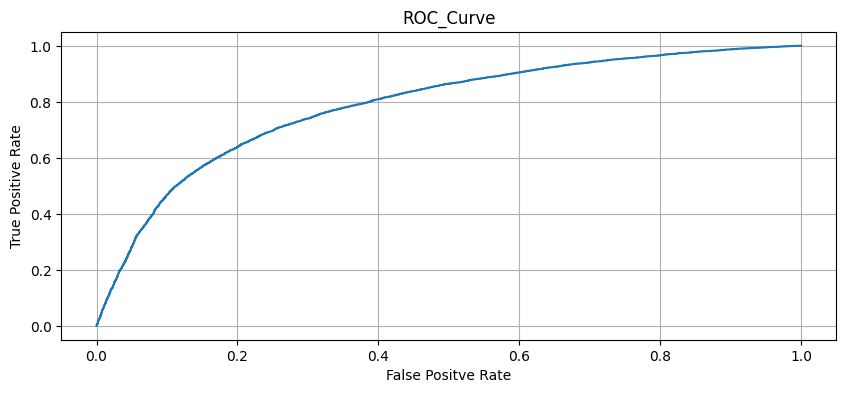

In [74]:
#ROC curve
fpr,tpr,threshhold=roc_curve(y_test,y_pred_prob_LR[:,1])
#plotting the fnr, fpr
plt.figure(figsize=(10,4))
plt.plot(fpr,tpr)
plt.title("ROC_Curve")
plt.xlabel("False Positve Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.show()

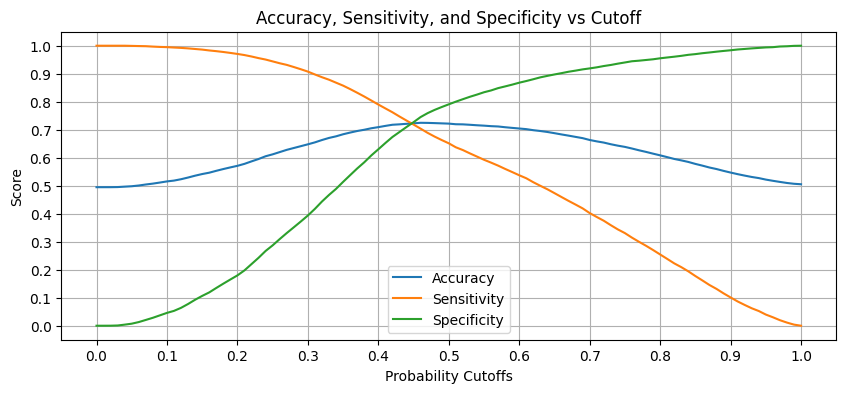

In [72]:
#identifying the probability cutoff
LR_cutoff_metrics=[]
for cut_off in probability_cut_offs:
  accuracy=accuracy_score(y_test,y_pred_prob_LR[:,1]>=cut_off)
  sensitivity=recall_score(y_test,y_pred_prob_LR[:,1]>=cut_off)
  specificity=recall_score(y_test,y_pred_prob_LR[:,1]>=cut_off,pos_label=0)
  LR_cutoff_metrics.append({
      "cutoff":cut_off,
      "accuracy":accuracy,
      "sensitivity":sensitivity,
      "specificity":specificity
  })
#creating a dataframe for differennt cutoffs
LR_cut_offs=pd.DataFrame(LR_cutoff_metrics)
#plotting to find the optimal one
plt.figure(figsize=(10,4))
plt.plot(LR_cut_offs["cutoff"],LR_cut_offs["accuracy"],label='Accuracy')
plt.plot(LR_cut_offs["cutoff"],LR_cut_offs["sensitivity"],label='Sensitivity')
plt.plot(LR_cut_offs["cutoff"],LR_cut_offs["specificity"],label='Specificity')
plt.xticks(np.arange(0,1.1,.1))
plt.yticks(np.arange(0,1.1,.1))
plt.xlabel("Probability Cutoffs")
plt.ylabel("Score")
plt.title("Accuracy, Sensitivity, and Specificity vs Cutoff")
plt.legend()
plt.grid(True)
plt.show()


Considering the Accuracy,Sensitivity, and Specificity plotting with probability cuoff, the **Optimal_Cutoff is 0.45**, and will use the same from next analysis.

In [80]:
# Evaluate and compare
#optimal_cutoff from "Accuracy, Sensitivity, and Specificity vs Cutoff"
optimal_cutoff_LR=0.45
optimal_cutoff_perf_LR=classification_report(y_test,y_pred_prob_LR[:,1]>=optimal_cutoff_LR)
print(f"Logistic Regression Model Performance:\n{optimal_cutoff_perf_LR}")
print(f"Support Vector Classifier Performance:\n{optimal_model_perf}")
print(f"Decision Tree Tuned Performance:\n{dt_model_perf_on_test_data}")

Logistic Regression Model Performance:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73     10405
           1       0.72      0.72      0.72     10189

    accuracy                           0.72     20594
   macro avg       0.72      0.72      0.72     20594
weighted avg       0.72      0.72      0.72     20594

Support Vector Classifier Performance:
              precision    recall  f1-score   support

           0       0.73      0.71      0.72     10405
           1       0.71      0.73      0.72     10189

    accuracy                           0.72     20594
   macro avg       0.72      0.72      0.72     20594
weighted avg       0.72      0.72      0.72     20594

Decision Tree Tuned Performance:
              precision    recall  f1-score   support

           0       0.64      0.65      0.64     10405
           1       0.64      0.63      0.63     10189

    accuracy                           0.64     20594
   macro avg     

### **6.3 Hyperparameter Tuning**

<font color = red>[8 Marks]</font>

Enhance the performance of the decision tree model by systematically exploring and selecting optimal hyperparameter values using Grid Search.

#### **6.3.1** Use grid search to find the best hyperparameter values <font color = red>[4 Marks]</font>

Perform hyperparameter tuning to see if the performance of the decision tree model can be improved. Tune for **at least 4 decision tree hyperparameters**.

In [62]:
# Use grid search to find best hyperparameters for decision tree model

# Define the parameter grid for the decision tree
param_grid={
    'max_depth':[3,5,7,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'criterion':['gini','entropy']

}

grid_search=GridSearchCV(
    estimator=dtc,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-2
)

grid_search.fit(X_train_scaled,y_train)

# Print the best hyperparameters
print(f"Best Hyperparameters:\n{grid_search.best_params_}")

Best Hyperparameters:
{'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}


#### **6.3.2** Build a decision tree model based on hyperparameter tuning results <font color = red>[2 Marks]</font>


In [63]:
# Use the best DT from grid search
DT_tuned=DecisionTreeClassifier(criterion='gini',max_depth=7,min_samples_leaf=1,min_samples_split=2,random_state=42)
DT_tuned.fit(X_train_scaled,y_train)

DecisionTreeClassifier(max_depth=7, random_state=42)

#### **6.3.3** Using the tuned model, make predictions and evaluate <font color="red">[2 Mark]</font>

Use the tuned model to directly predict the labels and evaluate the performance on both training and testing sets to check overfitting / underfitting.

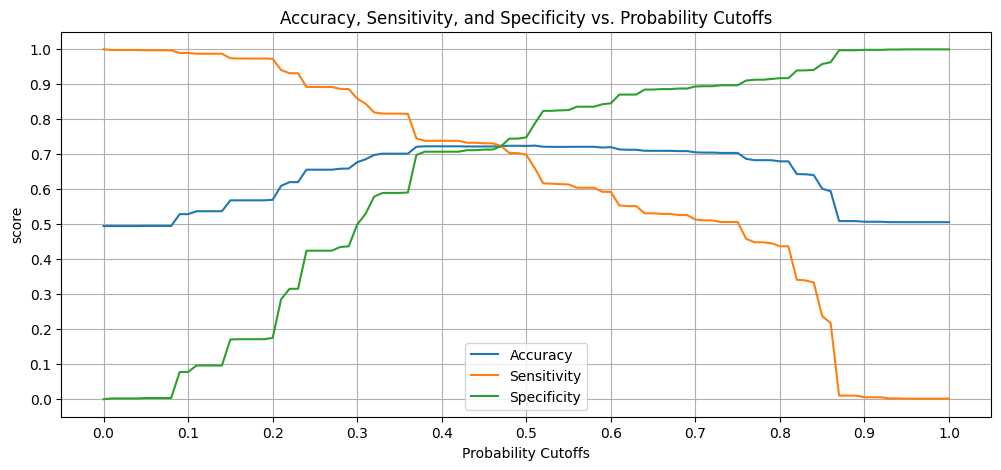

In [64]:
#test data prediction probability in DT_tuned model
y_test_pred_prob_DT_tuned=DT_tuned.predict_proba(X_test_scaled)
#identifying the perfect cutoff to classify
#metrics storing list
metrics_storage=[]
for cut_off in probability_cut_offs:
  accuracy=accuracy_score(y_test,y_test_pred_prob_DT_tuned[:,1]>=cut_off)
  sensitivity=recall_score(y_test,y_test_pred_prob_DT_tuned[:,1]>=cut_off)
  specificity=recall_score(y_test,y_test_pred_prob_DT_tuned[:,1]>=cut_off,pos_label=0)
  metrics_storage.append({
      "cutoff":cut_off,
      "accuracy":accuracy,
      "sensitivity":sensitivity,
      "specificity":specificity
  })
#creating dataframe
DT_tuned_metrics=pd.DataFrame(metrics_storage)

#plotting to find the best cutoff
plt.figure(figsize=(12,5))
plt.plot(DT_tuned_metrics['cutoff'],DT_tuned_metrics['accuracy'],label="Accuracy")
plt.plot(DT_tuned_metrics['cutoff'],DT_tuned_metrics['sensitivity'],label="Sensitivity")
plt.plot(DT_tuned_metrics['cutoff'],DT_tuned_metrics['specificity'],label="Specificity")
plt.title('Accuracy, Sensitivity, and Specificity vs. Probability Cutoffs')
plt.xlabel("Probability Cutoffs")
plt.ylabel("score")
plt.xticks(np.arange(0,1.1,.1))
plt.yticks(np.arange(0,1.1,.1))
plt.grid(True)
plt.legend()
plt.show()

 **Optimal Cutoff Note:** An optimal threshold of 0.465 (range 0.46–0.47) was chosen because it achieves the best balance between sensitivity and specificity (~73%) while maintaining peak accuracy.

In [65]:
# Evaluate the model performance on training set
y_train_pred_prob_DT_tuned=DT_tuned.predict_proba(X_train_scaled)
y_train_pred_DT_tuned=(y_train_pred_prob_DT_tuned[:,1]>=0.465).astype('int')
training_perf_DT_tuned=classification_report(y_train,y_train_pred_DT_tuned)
print(f"Tuned Model Performance on Training Dataset:\n{training_perf_DT_tuned}")

Tuned Model Performance on Training Dataset:
              precision    recall  f1-score   support

           0       0.75      0.73      0.74     24279
           1       0.73      0.75      0.74     23773

    accuracy                           0.74     48052
   macro avg       0.74      0.74      0.74     48052
weighted avg       0.74      0.74      0.74     48052



In [66]:
# Evaluate the model performance on test set
y_test_pred_DT_tuned=(y_test_pred_prob_DT_tuned[:,1]>=0.465).astype('int')
test_perf_DT_tuned=classification_report(y_test,y_test_pred_DT_tuned)
print(f"Tuned Model Performance on Test Dataset:\n{test_perf_DT_tuned}")

Tuned Model Performance on Test Dataset:
              precision    recall  f1-score   support

           0       0.73      0.72      0.73     10405
           1       0.72      0.72      0.72     10189

    accuracy                           0.72     20594
   macro avg       0.72      0.72      0.72     20594
weighted avg       0.72      0.72      0.72     20594



In [67]:
# # Check performance on training data
# y_train_pred_prob=svm.predict_proba(X_train_scaled)
# y_train_pred_prob_class=(y_train_pred_prob[:,1]>0.42).astype('int')
# training_perf=classification_report(y_train,y_train_pred_prob_class)
# print(training_perf)
# # Evaluate the model performance
# optimal_model_perf=classification_report(y_test,optimal_y_pred_class)
# print(optimal_model_perf)

#### **6.3.4** Optionally, use grid search to find the best hyperparameter values for SVM

Try to fine-tune SVM hyperparameters like kernels, `C` and `gamma`.

You can also check the performance of SVM with `RBF` kernel

Tune your third candidate model, if taken

## **7. Final Model Evaluation and Selection**

<font color = red>[2 Marks]</font>

Use you final models to make predictions on the test data. Evaluate the models, create model cards, and finally write your conclusive findings, results, and insights from the steps performed.

Include these in your report as well.

### **7.1 Evaluate the final models**

<font color = red>[2 Marks]</font>

Make predictions using the tuned models and selected features to check the training and testing performances and create model cards for both.

#### **7.1.1** Make final predictions and evaluate <font color="red">[2 Marks]</font>

Evaluate the performance of your final candidates

In [68]:
# Make predictions on test and train sets using all candidate models
# use the chosen optimal cutoff
svm_cutoff=0.42
tree_cutoff=0.465

#SVM model prediction and performance
SVM_final_train_perf=classification_report(y_train,(svm.predict_proba(X_train_scaled)[:,1]>=svm_cutoff))
print(f"SVC final performance on training data:\n{SVM_final_train_perf}")
SVM_final_test_perf=classification_report(y_test,(svm.predict_proba(X_test_scaled)[:,1]>=svm_cutoff))
print(f"SVM final performance on test data:\n{SVM_final_test_perf}")

#DT model prediction and performance
DT_final_train_perf=classification_report(y_train,(DT_tuned.predict_proba(X_train_scaled)[:,1]>=tree_cutoff))
print(f"\nDecision Tree final performance on training data:\n{DT_final_train_perf}")
DT_final_test_perf=classification_report(y_test,(DT_tuned.predict_proba(X_test_scaled)[:,1]>=tree_cutoff))
print(f"Decision Tree final performance on test data:\n{DT_final_test_perf}")

SVC final performance on training data:
              precision    recall  f1-score   support

           0       0.74      0.71      0.73     24279
           1       0.72      0.75      0.73     23773

    accuracy                           0.73     48052
   macro avg       0.73      0.73      0.73     48052
weighted avg       0.73      0.73      0.73     48052

SVM final performance on test data:
              precision    recall  f1-score   support

           0       0.73      0.71      0.72     10405
           1       0.71      0.73      0.72     10189

    accuracy                           0.72     20594
   macro avg       0.72      0.72      0.72     20594
weighted avg       0.72      0.72      0.72     20594


Decision Tree final performance on training data:
              precision    recall  f1-score   support

           0       0.75      0.73      0.74     24279
           1       0.73      0.75      0.74     23773

    accuracy                           0.74     48052
 

### **7.2 Conclusion**

#### **7.2.1** Model Cards

Create model cards for all your candidate models. Include this in your report.

Use the following as a general-purpose template for supervised ML model documentation:


**Model Card: [Model name]**

**Model overview:**
Brief description of the model, its purpose, and context.

**Intended use:**

* Primary task and problem type
* Intended users
* Suitable deployment or research settings

**Data and features:**

* Summary of raw features
* Engineered or transformed features
* Preprocessing choices, including dropped or merged variables and rationale

**Model configuration:**

* Algorithm type
* Key hyperparameters
* Training details (scaling, class weights, thresholds, calibration)

**Performance:**

* Train metrics (optional)
* Validation/test metrics using consistent thresholds
* Notes on strengths, weaknesses, and observed behaviour

**Limitations and considerations:**

* Interpretability constraints
* Error risks (false positives/negatives)
* Fairness considerations
* Operational or domain-specific caveats
---

#### **7.2.2** Conclusions and Outcomes

Try to answer the following questions in your answer. Include this in the report.

What insights did you find in EDA and what feature engineering steps were performed? Describe your choice of models and the performance of baseline models. Did you find overfitting? How was it handled and what was the result of tuning? Was the data sufficent? Is a linear model sufficient? What model did you choose? Explain the final outcomes.